# Supplementary File S1 — Data Preprocessing, Model Architecture, Training, and Evaluation

**Indian Cuisine Classification Framework — Full Benchmark Pipeline**

This notebook contains the complete, reproducible pipeline used to produce the benchmark
results reported in Sections 4 and 5 of the paper: dataset cleaning, stratified splitting,
the hybrid CNN-Transformer architecture, the training loop, and evaluation (confusion matrix,
per-class accuracy, classification report).

This is the reference implementation. Instructors do not need students to run this notebook
in full — Lessons 1 and 3 (Supplementary Files S2 and S4) use the pre-computed outputs
produced here (test predictions, `training_log.csv`) so that students without GPU access can
still complete those activities.

**Environment: Google Colab.** Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU.

This version pulls the dataset directly from Kaggle via the Kaggle API and stores all outputs
in Google Drive so they persist after the Colab runtime disconnects (Colab's local /content
storage is wiped when the session ends).


In [ ]:
# ===== CELL 1: MOUNT + VERIFY DRIVE =====
from google.colab import drive
import os
drive.mount('/content/drive')
assert os.path.ismount('/content/drive'), "Drive NOT live — re-run THIS cell before anything else."
print("Drive is truly mounted ->", os.path.realpath('/content/drive/MyDrive'))

Mounted at /content/drive
Drive is truly mounted -> /content/drive/MyDrive


In [ ]:
# ===== CELL 2: INSTALL PACKAGES =====
!pip install -q kaggle timm
print("Packages installed.")

Packages installed.


In [ ]:
# ===== CELL 3: IMPORTS =====
import os, sys, time, json, shutil, zipfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import warnings; warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid"); plt.rcParams['figure.figsize'] = (14, 6)
print(f"Torch {torch.__version__} | CUDA {torch.cuda.is_available()} | "
      f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Torch 2.11.0+cu128 | CUDA True | Tesla T4


In [ ]:
# ===== CELL 4: CONFIG  =====
class Config:
    DATASET_NAME      = 'indianfooddataset'
    DRIVE_PROJECT_DIR = '/content/drive/MyDrive/CEP_Food_Dataset'
    INPUT_DIR   = '/content/data'
    CLEANED_DIR = '/content/cleaned_data'     # local scratch (valid full-res images)
    RESIZED_DIR = '/content/resized_256'      # local scratch (256px cache, fast reads)
    MODEL_DIR   = f'{DRIVE_PROJECT_DIR}/models'
    PLOT_DIR    = f'{DRIVE_PROJECT_DIR}/outputs'

    NUM_CLASSES = 100
    IMAGE_SIZE  = 224
    BATCH_SIZE  = 64
    EPOCHS      = 50
    LR          = 1e-4
    BACKBONE    = 'resnet50'
    DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    assert os.path.ismount('/content/drive'), "Run Cell 1 (mount) BEFORE Config."
    for _d in (CLEANED_DIR, RESIZED_DIR, MODEL_DIR, PLOT_DIR):
        os.makedirs(_d, exist_ok=True)

cfg = Config()
print(f"Config OK | device {cfg.DEVICE} | outputs -> {cfg.PLOT_DIR}")

Config OK | device cuda | outputs -> /content/drive/MyDrive/CEP_Food_Dataset/outputs


In [ ]:
# ===== CELL 5: CACHE CHECK  =====
ZIP_DRIVE  = f'{cfg.DRIVE_PROJECT_DIR}/resized_256.zip'
STATS_PATH = f'{cfg.MODEL_DIR}/dataset_stats.json'

if os.path.exists(ZIP_DRIVE):
    t = time.time()
    with zipfile.ZipFile(ZIP_DRIVE) as z: z.extractall(cfg.RESIZED_DIR + '/..')
    HAVE_CACHE = os.path.isdir(cfg.RESIZED_DIR) and len(os.listdir(cfg.RESIZED_DIR)) > 0
    print(f"Cache pulled from Drive in {time.time()-t:.0f}s -> SKIPPING download/clean/resize.")
else:
    HAVE_CACHE = False
    print("No cache on Drive yet. Cells 6–12 will run ONCE to build it.")
print("HAVE_CACHE =", HAVE_CACHE)

No cache on Drive yet. Cells 6–12 will run ONCE to build it.
HAVE_CACHE = False


In [ ]:
# ===== CELL 6: KAGGLE DOWNLOAD =====
if not HAVE_CACHE:
    os.makedirs('/root/.kaggle', exist_ok=True)
    KAGGLE_TOKEN = "KGAT_4c803e055563717256a8cd0803c1a847"
    with open('/root/.kaggle/access_token', 'w') as f: f.write(KAGGLE_TOKEN)
    os.chmod('/root/.kaggle/access_token', 0o600)
    SLUG = 'snehaattarde/IndianFoodDataset'
    !kaggle datasets download -d {SLUG} -p /content/data --unzip
    print("Downloaded to /content/data")
else:
    print("Skipped (cache exists).")

Dataset URL: https://www.kaggle.com/datasets/snehaattarde/IndianFoodDataset
License(s): unknown
100% 19.6G/19.6G [04:18<00:00, 81.2MB/s]

Downloaded to /content/data


In [ ]:
# ===== CELL 7: LOCATE DATA   =====
if not HAVE_CACHE:
    items = os.listdir(cfg.INPUT_DIR)
    zips  = [f for f in items if f.endswith('.zip')]
    if zips:
        with zipfile.ZipFile(os.path.join(cfg.INPUT_DIR, zips[0])) as zf: zf.extractall('/content/extracted')
        c = os.listdir('/content/extracted')
        DATA_DIR = os.path.join('/content/extracted', c[0]) if len(c)==1 and os.path.isdir(os.path.join('/content/extracted',c[0])) else '/content/extracted'
    else:
        folders = [f for f in items if os.path.isdir(os.path.join(cfg.INPUT_DIR, f))]
        DATA_DIR = os.path.join(cfg.INPUT_DIR, folders[0]) if len(folders)==1 else cfg.INPUT_DIR
    print("DATA_DIR =", DATA_DIR)
else:
    print("Skipped (cache exists).")

DATA_DIR = /content/data/IndianFoodDataset


Analyzing:   0%|          | 0/100 [00:00<?, ?it/s]

100 classes | 4,577 images | 21.09 GB


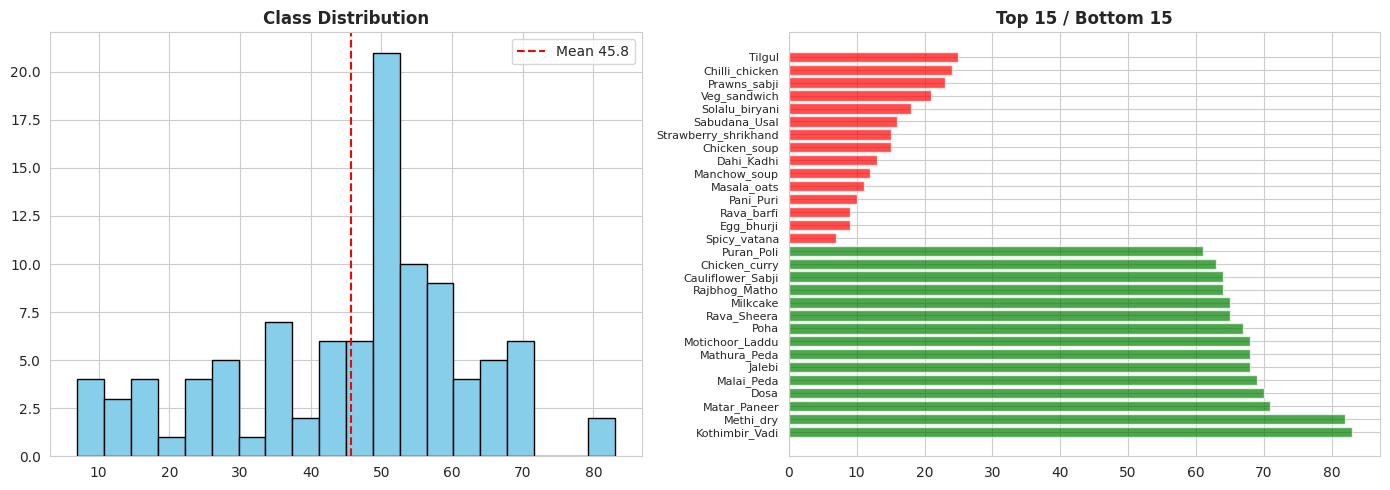

In [ ]:
# ===== CELL 8: ANALYZE DATASET + class_metadata.csv + plot 01  =====
if not HAVE_CACHE:
    classes = sorted([f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))])
    rows = []
    for cls in tqdm(classes, desc="Analyzing"):
        cp = os.path.join(DATA_DIR, cls)
        imgs = [f for f in os.listdir(cp) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
        rows.append({'class': cls, 'images': len(imgs),
                     'size_mb': sum(os.path.getsize(os.path.join(cp,i)) for i in imgs)/1e6})
    df = pd.DataFrame(rows)
    print(f"{len(df)} classes | {df['images'].sum():,} images | {df['size_mb'].sum()/1000:.2f} GB")
    df.to_csv(f'{cfg.PLOT_DIR}/class_metadata.csv', index=False)

    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    ax[0].hist(df['images'], bins=20, color='skyblue', edgecolor='black')
    ax[0].axvline(df['images'].mean(), color='red', ls='--', label=f"Mean {df['images'].mean():.1f}")
    ax[0].set_title('Class Distribution', fontweight='bold'); ax[0].legend()
    tb = pd.concat([df.sort_values('images',ascending=False).head(15), df.sort_values('images').head(15)])
    ax[1].barh(range(len(tb)), tb['images'], color=['green']*15+['red']*15, alpha=.7)
    ax[1].set_yticks(range(len(tb))); ax[1].set_yticklabels(tb['class'], fontsize=8)
    ax[1].set_title('Top 15 / Bottom 15', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{cfg.PLOT_DIR}/01_distribution.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print("Skipped (cache exists).")

Scanning:   0%|          | 0/100 [00:00<?, ?it/s]

Total 4,577 | Valid 4,577 | Corrupted 0


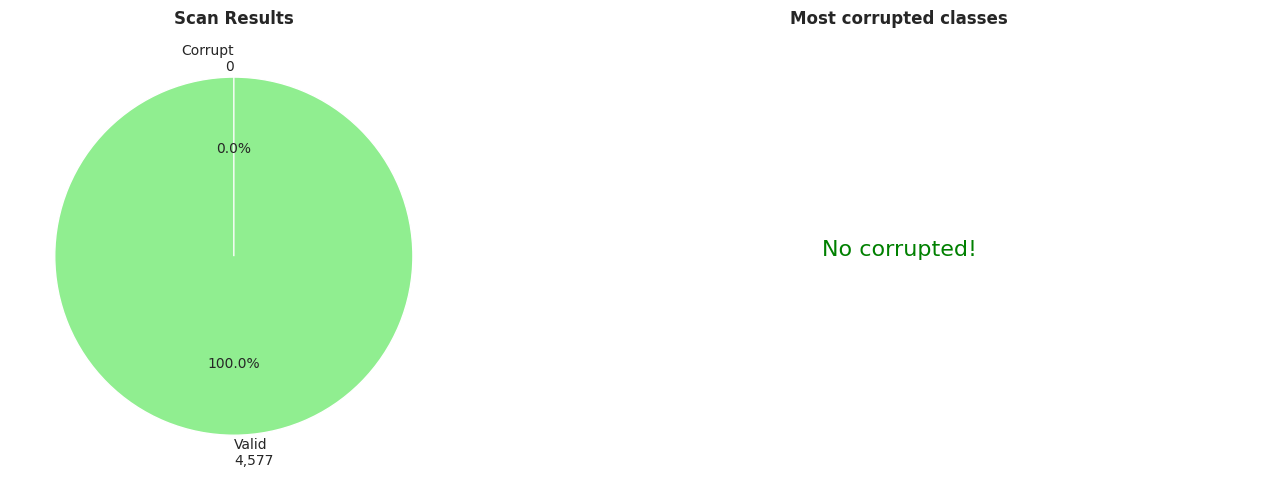

In [ ]:
# ===== CELL 9: SCAN CORRUPTED + plot 02  =====
if not HAVE_CACHE:
    def check_img(p):
        try:
            s = os.path.getsize(p)
            if s == 0: return True
            if s < 100: return True
            with Image.open(p) as im: im.verify()
            with Image.open(p) as im: im.load(); im.convert('RGB')
            return False
        except: return True

    corrupted, valid, total = [], [], 0
    for cls in tqdm(classes, desc="Scanning"):
        cp = os.path.join(DATA_DIR, cls)
        for img in os.listdir(cp):
            if img.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
                total += 1; ip = os.path.join(cp, img)
                (corrupted if check_img(ip) else valid).append({'class':cls,'file':img,'path':ip})
    print(f"Total {total:,} | Valid {len(valid):,} | Corrupted {len(corrupted):,}")

    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    ax[0].pie([len(valid), len(corrupted)], labels=[f'Valid\n{len(valid):,}', f'Corrupt\n{len(corrupted):,}'],
              colors=['#90EE90','#FFB6C1'], autopct='%1.1f%%', startangle=90)
    ax[0].set_title('Scan Results', fontweight='bold')
    if corrupted:
        bc = defaultdict(int)
        for c in corrupted: bc[c['class']] += 1
        top = sorted(bc.items(), key=lambda x:-x[1])[:15]
        cn, ct = zip(*top); ax[1].barh(range(len(cn)), ct, color='salmon', alpha=.7)
        ax[1].set_yticks(range(len(cn))); ax[1].set_yticklabels(cn, fontsize=8)
    else:
        ax[1].text(.5,.5,'No corrupted!', ha='center', color='green', fontsize=16); ax[1].axis('off')
    ax[1].set_title('Most corrupted classes', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{cfg.PLOT_DIR}/02_scan.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print("Skipped (cache exists).")

In [ ]:
# ===== CELL 10: COPY VALID IMAGES -> cleaned_data  =====
failed = []
for cls in set(v['class'] for v in valid):
    os.makedirs(os.path.join(cfg.CLEANED_DIR, cls), exist_ok=True)

copied = 0
for v in tqdm(valid, desc="Copying"):
    try:
        shutil.copy2(v['path'], os.path.join(cfg.CLEANED_DIR, v['class'], v['file']))
        copied += 1
    except Exception as e:
        failed.append({'class': v['class'], 'file': v['file'], 'path': v['path'], 'error': str(e)})

print(f"Copied {copied:,} valid images -> {cfg.CLEANED_DIR}")
if failed:
    print(f"\n{len(failed)} failed:")
    for f in failed:
        print(f"  {f['class']}/{f['file']} -> {f['error']}")
        print(f"  exists on disk? {os.path.exists(f['path'])}")

Copying:   0%|          | 0/4577 [00:00<?, ?it/s]

Copied 4,577 valid images -> /content/cleaned_data


In [ ]:
# ===== CELL 11: VERIFY + save dataset_stats.json  =====
if not HAVE_CACHE:
    verified = 0
    for cls in tqdm(os.listdir(cfg.CLEANED_DIR), desc="Verifying"):
        cp = os.path.join(cfg.CLEANED_DIR, cls)
        if os.path.isdir(cp):
            for img in os.listdir(cp):
                try:
                    with Image.open(os.path.join(cp,img)) as im: im.verify(); im.load()
                    verified += 1
                except: pass
    with open(STATS_PATH, 'w') as f:
        json.dump({'total':total, 'valid':len(valid), 'corrupted':len(corrupted), 'verified':verified}, f)
    print(f"Verified {verified:,}/{copied:,} | stats saved to Drive")
else:
    print("Skipped (cache exists).")

Verifying:   0%|          | 0/100 [00:00<?, ?it/s]

Verified 7/4,577 | stats saved to Drive


In [ ]:
# ===== CELL 12: RESIZE TO 256 + ZIP TO DRIVE  =====
if not HAVE_CACHE:
    jobs = []
    for cls in sorted(os.listdir(cfg.CLEANED_DIR)):
        sp, dp = os.path.join(cfg.CLEANED_DIR, cls), os.path.join(cfg.RESIZED_DIR, cls)
        if not os.path.isdir(sp): continue
        os.makedirs(dp, exist_ok=True)
        for f in os.listdir(sp):
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
                jobs.append((os.path.join(sp,f), os.path.join(dp, os.path.splitext(f)[0]+'.jpg')))

    def resize_one(j):
        s, d = j
        try:
            with Image.open(s) as im: im.convert('RGB').resize((256,256)).save(d, 'JPEG', quality=90)
        except: pass
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(resize_one, jobs), total=len(jobs), desc='Resizing'))

    zpath = '/content/resized_256.zip'
    with zipfile.ZipFile(zpath, 'w', zipfile.ZIP_STORED) as z:   # STORED: jpgs already compressed
        for cls in os.listdir(cfg.RESIZED_DIR):
            cp = os.path.join(cfg.RESIZED_DIR, cls)
            for f in os.listdir(cp): z.write(os.path.join(cp,f), arcname=os.path.join(cls,f))
    shutil.copy(zpath, ZIP_DRIVE)
    print(f"Resized cache built + pushed to Drive -> {ZIP_DRIVE}  (reruns now skip cells 6–12)")
else:
    print("Skipped (cache exists).")

Resizing:   0%|          | 0/4577 [00:00<?, ?it/s]

Resized cache built + pushed to Drive -> /content/drive/MyDrive/CEP_Food_Dataset/resized_256.zip  (reruns now skip cells 6–12)


In [ ]:
# ===== CELL 13: BUILD PATHS + class_names.txt =====
paths, labels, class_names = [], [], []
for idx, cls in enumerate(sorted(os.listdir(cfg.RESIZED_DIR))):
    class_names.append(cls)
    cp = os.path.join(cfg.RESIZED_DIR, cls)
    for f in os.listdir(cp):
        paths.append(os.path.join(cp, f)); labels.append(idx)
cfg.NUM_CLASSES = len(class_names)
with open(f'{cfg.PLOT_DIR}/class_names.txt', 'w') as f: f.write('\n'.join(class_names))
print(f"{len(paths):,} images | {cfg.NUM_CLASSES} classes")

4,577 images | 100 classes


Train 3,203 | Val 687 | Test 687


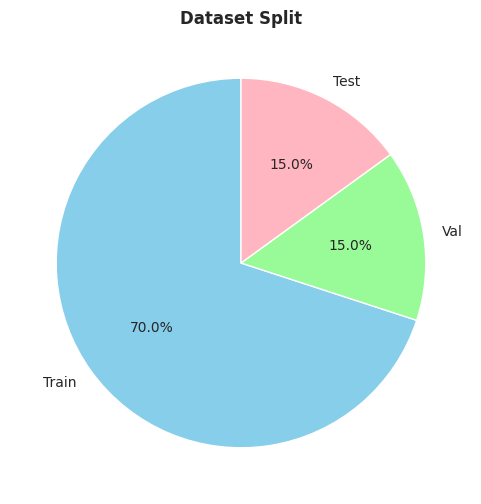

In [ ]:
# ===== CELL 14: SPLIT 70/15/15 + plot 04  =====
X_tr, X_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_tst, y_val, y_tst = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
print(f"Train {len(X_tr):,} | Val {len(X_val):,} | Test {len(X_tst):,}")

plt.figure(figsize=(7,6))
plt.pie([len(X_tr),len(X_val),len(X_tst)], labels=['Train','Val','Test'],
        colors=['#87CEEB','#98FB98','#FFB6C1'], autopct='%1.1f%%', startangle=90)
plt.title('Dataset Split', fontweight='bold')
plt.savefig(f'{cfg.PLOT_DIR}/04_split.png', dpi=200, bbox_inches='tight'); plt.show()

In [ ]:
# ===== CELL 15: FAST TRANSFORMS =====
_m, _s = [0.485,0.456,0.406], [0.229,0.224,0.225]
tr_tfm = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(_m, _s)])
val_tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(), transforms.Normalize(_m, _s)])
print("Transforms ready.")

Transforms ready.


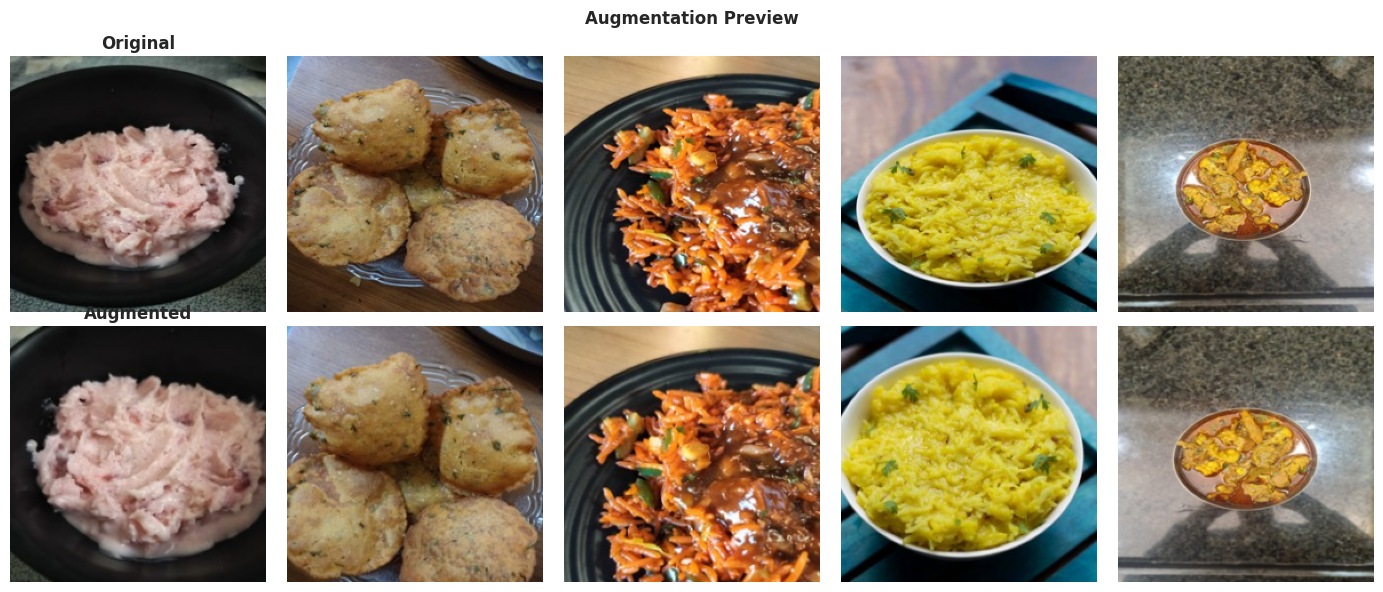

In [ ]:
# ===== CELL 16: AUGMENTATION PREVIEW + plot 05 =====
fig, ax = plt.subplots(2, 5, figsize=(14,6))
viz = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.7,1.0)), transforms.RandomHorizontalFlip()])
for i in range(5):
    img = Image.open(paths[np.random.randint(len(paths))]).convert('RGB')
    ax[0,i].imshow(img.resize((224,224))); ax[0,i].axis('off')
    ax[1,i].imshow(viz(img)); ax[1,i].axis('off')
    if i==0: ax[0,i].set_title('Original', fontweight='bold'); ax[1,i].set_title('Augmented', fontweight='bold')
plt.suptitle('Augmentation Preview', fontweight='bold'); plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/05_augmentation.png', dpi=200, bbox_inches='tight'); plt.show()

In [ ]:
# ===== CELL 17: DATASET + DATALOADERS =====
class FoodDS(Dataset):
    def __init__(self, paths, labels, tfm=None):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return (self.tfm(img) if self.tfm else img), self.labels[i]

tr_ld  = DataLoader(FoodDS(X_tr, y_tr, tr_tfm),   batch_size=cfg.BATCH_SIZE, shuffle=True,
                    num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=4)
val_ld = DataLoader(FoodDS(X_val, y_val, val_tfm), batch_size=128, shuffle=False,
                    num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=4)
tst_ld = DataLoader(FoodDS(X_tst, y_tst, val_tfm), batch_size=128, shuffle=False,
                    num_workers=2, pin_memory=True)
print(f"Loaders: {len(tr_ld)} train / {len(val_ld)} val / {len(tst_ld)} test batches")

Loaders: 51 train / 6 val / 6 test batches


In [ ]:
# ===== CELL 18: MODEL DEFINITION (CNN + Transformer) =====
class PE(nn.Module):
    def __init__(self, c, d): super().__init__(); self.p = nn.Conv2d(c, d, 1, 1)
    def forward(self, x): return self.p(x).flatten(2).transpose(1, 2)

class TB(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.a = nn.MultiheadAttention(d, h, 0.1)
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.m = nn.Sequential(nn.Linear(d, d*4), nn.GELU(), nn.Dropout(0.1), nn.Linear(d*4, d), nn.Dropout(0.1))
    def forward(self, x):
        xn = self.n1(x).transpose(0, 1)
        a, _ = self.a(xn, xn, xn)
        x = x + a.transpose(0, 1)
        return x + self.m(self.n2(x))

class Model(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        try:    bb = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        except: bb = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(bb.children())[:-2])
        self.pe = PE(2048, 768)
        with torch.no_grad():
            o = self.cnn(torch.randn(1, 3, 224, 224)); n = o.shape[2]*o.shape[3]
        self.cls_t = nn.Parameter(torch.randn(1, 1, 768))
        self.pos   = nn.Parameter(torch.randn(1, n+1, 768))
        self.d = nn.Dropout(0.1)
        self.t = nn.ModuleList([TB(768, 12) for _ in range(6)])
        self.n = nn.LayerNorm(768)
        self.h = nn.Sequential(nn.Linear(768, 384), nn.GELU(), nn.Dropout(0.1), nn.Linear(384, n_cls))
    def forward(self, x):
        B = x.shape[0]
        x = self.pe(self.cnn(x))
        x = torch.cat([self.cls_t.expand(B, -1, -1), x], 1) + self.pos
        x = self.d(x)
        for t in self.t: x = t(x)
        return self.h(self.n(x[:, 0]))
print("Model classes defined.")

Model classes defined.


In [ ]:
# ===== CELL 19: BUILD MODEL =====
model = Model(cfg.NUM_CLASSES).to(cfg.DEVICE)
print(f"Model built: {sum(p.numel() for p in model.parameters()):,} params")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


Model built: 67,983,396 params


In [ ]:
# ===== CELL 20: TRAIN / VAL FUNCTIONS (AMP) =====
def train_ep(model, ld, crit, opt, dev):
    model.train(); tl=c=t=0
    for x, y in tqdm(ld, desc="train", leave=False):
        x, y = x.to(dev, non_blocking=True), y.to(dev, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            o = model(x); loss = crit(o, y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tl += loss.item()*x.size(0); c += (o.argmax(1)==y).sum().item(); t += y.size(0)
    return tl/t, 100*c/t

def val(model, ld, crit, dev):
    model.eval(); tl=c=t=0
    with torch.no_grad():
        for x, y in ld:
            x, y = x.to(dev, non_blocking=True), y.to(dev, non_blocking=True)
            with torch.cuda.amp.autocast():
                o = model(x); loss = crit(o, y)
            tl += loss.item()*x.size(0); c += (o.argmax(1)==y).sum().item(); t += y.size(0)
    return tl/t, 100*c/t
print("Train/val functions ready.")

Train/val functions ready.


In [ ]:
# ===== CELL 21: SPEED SANITY CHECK  =====
scaler = torch.cuda.amp.GradScaler()
t0 = time.time()
xb, yb = next(iter(tr_ld))
print(f"1 batch load: {time.time()-t0:.1f}s  (was ~10s before)")
xb, yb = xb.to(cfg.DEVICE), yb.to(cfg.DEVICE)
t0 = time.time()
with torch.cuda.amp.autocast(): loss = nn.CrossEntropyLoss()(model(xb), yb)
scaler.scale(loss).backward(); torch.cuda.synchronize()
print(f"1 train step: {time.time()-t0:.2f}s  |  ~{len(tr_ld)} steps/epoch")

1 batch load: 1.0s  (was ~10s before)
1 train step: 4.51s  |  ~51 steps/epoch


In [ ]:
# ===== CELL 22: TRAINING =====
torch.backends.cudnn.benchmark = True
crit   = nn.CrossEntropyLoss()
opt    = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=0.01)
sch    = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler()

LOCAL_CKPT  = '/content/checkpoint.pth'          # instant, survives Ctrl+C
DRIVE_CKPT  = f'{cfg.MODEL_DIR}/checkpoint.pth'   # survives full disconnect
BEST_PATH   = f'{cfg.MODEL_DIR}/best.pth'
HIST_PATH   = f'{cfg.MODEL_DIR}/hist.json'
DRIVE_EVERY = 3                                   # raise if Drive upload feels slow

hist = {'trl':[], 'tra':[], 'vl':[], 'va':[], 'epoch_val':[]}

def save_ckpt(e, best, to_drive):
    torch.save({'epoch':e, 'best_va':best, 'model_state':model.state_dict(),
                'opt_state':opt.state_dict(), 'sch_state':sch.state_dict(),
                'scaler_state':scaler.state_dict()}, LOCAL_CKPT)
    if to_drive:
        shutil.copy(LOCAL_CKPT, DRIVE_CKPT)
        with open(HIST_PATH, 'w') as f: json.dump(hist, f)

# resume: prefer local (same session) else Drive (fresh VM). Delete both to start over.
start, best = 1, 0.0
src = LOCAL_CKPT if os.path.exists(LOCAL_CKPT) else (DRIVE_CKPT if os.path.exists(DRIVE_CKPT) else None)
if src:
    ck = torch.load(src, map_location=cfg.DEVICE)
    model.load_state_dict(ck['model_state']); opt.load_state_dict(ck['opt_state'])
    sch.load_state_dict(ck['sch_state']); scaler.load_state_dict(ck['scaler_state'])
    start, best = ck['epoch']+1, ck['best_va']
    if os.path.exists(HIST_PATH):
        with open(HIST_PATH) as f: hist = json.load(f)
    print(f"Resuming from epoch {start} | best {best:.2f}%  [{src}]")
else:
    print("No checkpoint -> fresh start from epoch 1")

for e in range(start, cfg.EPOCHS + 1):
    t0 = time.time()
    trl, tra = train_ep(model, tr_ld, crit, opt, cfg.DEVICE)
    hist['trl'].append(trl); hist['tra'].append(tra)
    msg = f"Epoch {e:>2}/{cfg.EPOCHS} | train {tra:5.2f}% loss {trl:.3f} | {time.time()-t0:4.0f}s"
    if e % 3 == 0 or e == cfg.EPOCHS:
        vl, va = val(model, val_ld, crit, cfg.DEVICE)
        hist['vl'].append(vl); hist['va'].append(va); hist['epoch_val'].append(e)
        msg += f" | val {va:5.2f}%"
        if va > best:
            best = va; torch.save(model.state_dict(), BEST_PATH); msg += "  <- best"
    sch.step()
    save_ckpt(e, best, to_drive=(e % DRIVE_EVERY == 0 or e == cfg.EPOCHS))
    print(msg)

# final training log for downstream
log = pd.DataFrame({'epoch': range(1, len(hist['trl'])+1), 'train_loss': hist['trl'], 'train_acc': hist['tra']})
vlog = pd.DataFrame({'epoch': hist['epoch_val'], 'val_loss': hist['vl'], 'val_acc': hist['va']})
log.merge(vlog, on='epoch', how='left').to_csv(f'{cfg.PLOT_DIR}/training_log.csv', index=False)
print(f"\nDone. Best val {best:.2f}% | training_log.csv saved")

No checkpoint -> fresh start from epoch 1


train:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch  1/50 | train  5.59% loss 4.419 |   33s


train:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch  2/50 | train 61.47% loss 2.210 |   22s


...

Epoch 48/50 | train 99.31% loss 0.028 |   25s | val 89.23%


train:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch 49/50 | train 99.72% loss 0.019 |   25s


train:   0%|          | 0/51 [00:00<?, ?it/s]

Epoch 50/50 | train 99.63% loss 0.022 |   26s | val 88.36%

Done. Best val 91.41% | training_log.csv saved


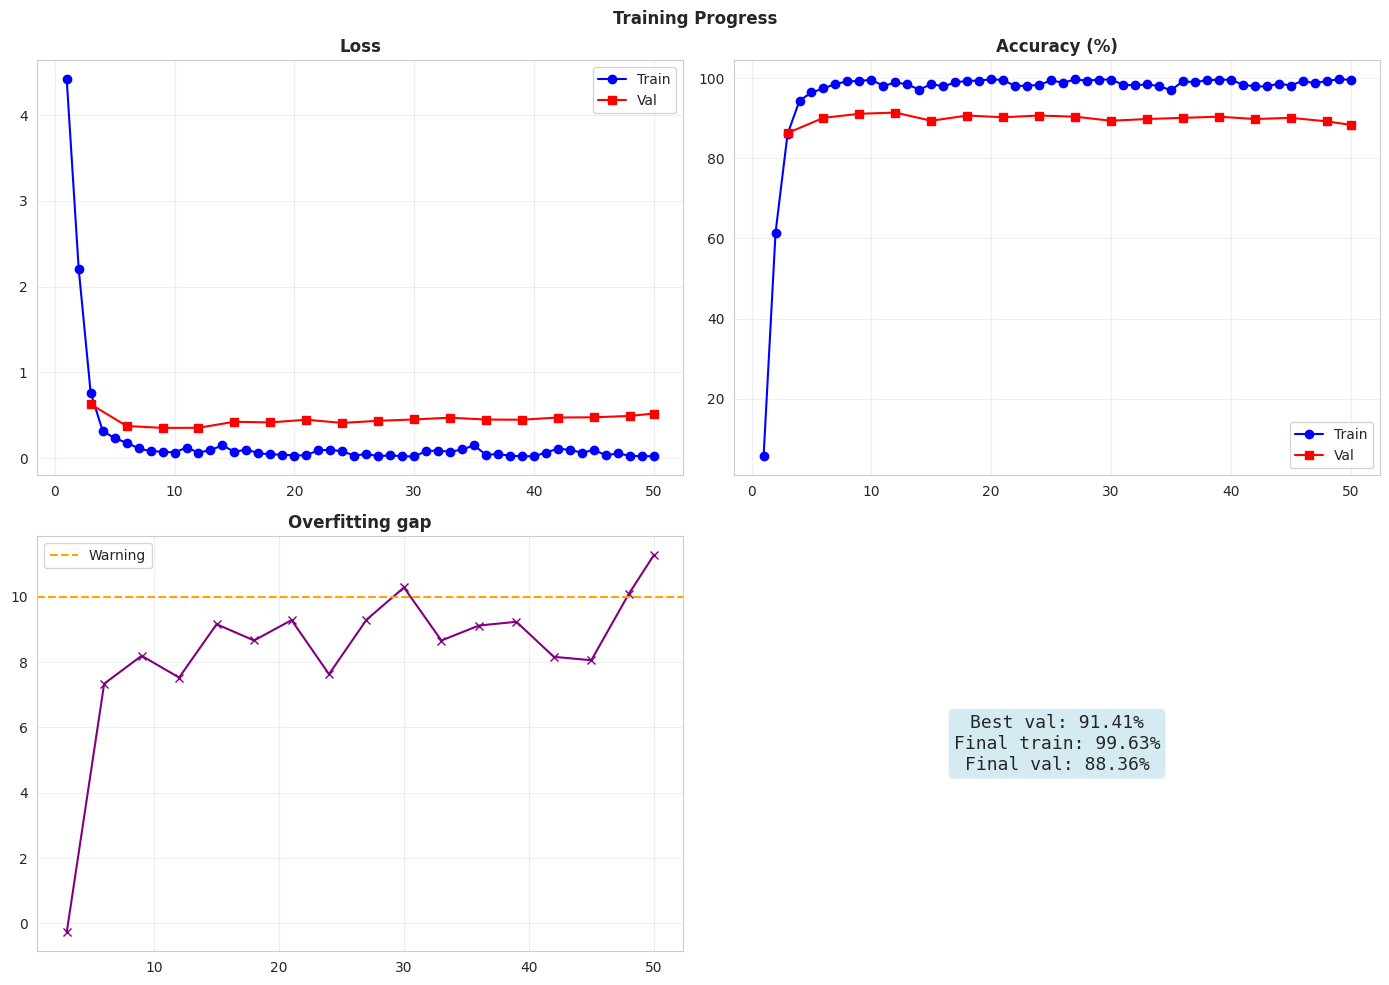

In [ ]:
# ===== CELL 23: PROGRESS PLOTS + plot 06 =====
ep   = list(range(1, len(hist['trl'])+1))
vep  = hist['epoch_val']
fig, ax = plt.subplots(2, 2, figsize=(14,10))
ax[0,0].plot(ep, hist['trl'], 'b-o', label='Train'); ax[0,0].plot(vep, hist['vl'], 'r-s', label='Val')
ax[0,0].set_title('Loss', fontweight='bold'); ax[0,0].legend(); ax[0,0].grid(alpha=.3)
ax[0,1].plot(ep, hist['tra'], 'b-o', label='Train'); ax[0,1].plot(vep, hist['va'], 'r-s', label='Val')
ax[0,1].set_title('Accuracy (%)', fontweight='bold'); ax[0,1].legend(); ax[0,1].grid(alpha=.3)
tra_at_v = [hist['tra'][e-1] for e in vep]
ax[1,0].plot(vep, np.array(tra_at_v)-np.array(hist['va']), 'purple', marker='x')
ax[1,0].axhline(10, color='orange', ls='--', label='Warning'); ax[1,0].set_title('Overfitting gap', fontweight='bold'); ax[1,0].legend(); ax[1,0].grid(alpha=.3)
ax[1,1].axis('off')
ax[1,1].text(.5,.5, f"Best val: {best:.2f}%\nFinal train: {hist['tra'][-1]:.2f}%\n"
             f"Final val: {hist['va'][-1] if hist['va'] else float('nan'):.2f}%",
             ha='center', va='center', fontsize=13, family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=.5))
plt.suptitle('Training Progress', fontweight='bold'); plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/06_progress_final.png', dpi=200, bbox_inches='tight'); plt.show()

In [ ]:
# ===== CELL 24: EVALUATE ON TEST + test_predictions.csv =====
model.load_state_dict(torch.load(BEST_PATH)); model.eval()
preds, lbls, probs = [], [], []
with torch.no_grad():
    for x, y in tqdm(tst_ld, desc='Testing'):
        o = model(x.to(cfg.DEVICE)); p = torch.softmax(o, 1)
        preds.extend(o.argmax(1).cpu().numpy()); lbls.extend(y.numpy()); probs.extend(p.cpu().numpy())
acc = accuracy_score(lbls, preds)
print(f"Test Accuracy: {acc*100:.2f}%")
pd.DataFrame({'true_label_idx':lbls, 'pred_label_idx':preds,
              'true_class':[class_names[i] for i in lbls], 'pred_class':[class_names[i] for i in preds],
              'confidence':[max(p) for p in probs]}).to_csv(f'{cfg.PLOT_DIR}/test_predictions.csv', index=False)
print("Saved: test_predictions.csv")

Testing:   0%|          | 0/6 [00:00<?, ?it/s]

Test Accuracy: 91.41%
Saved: test_predictions.csv


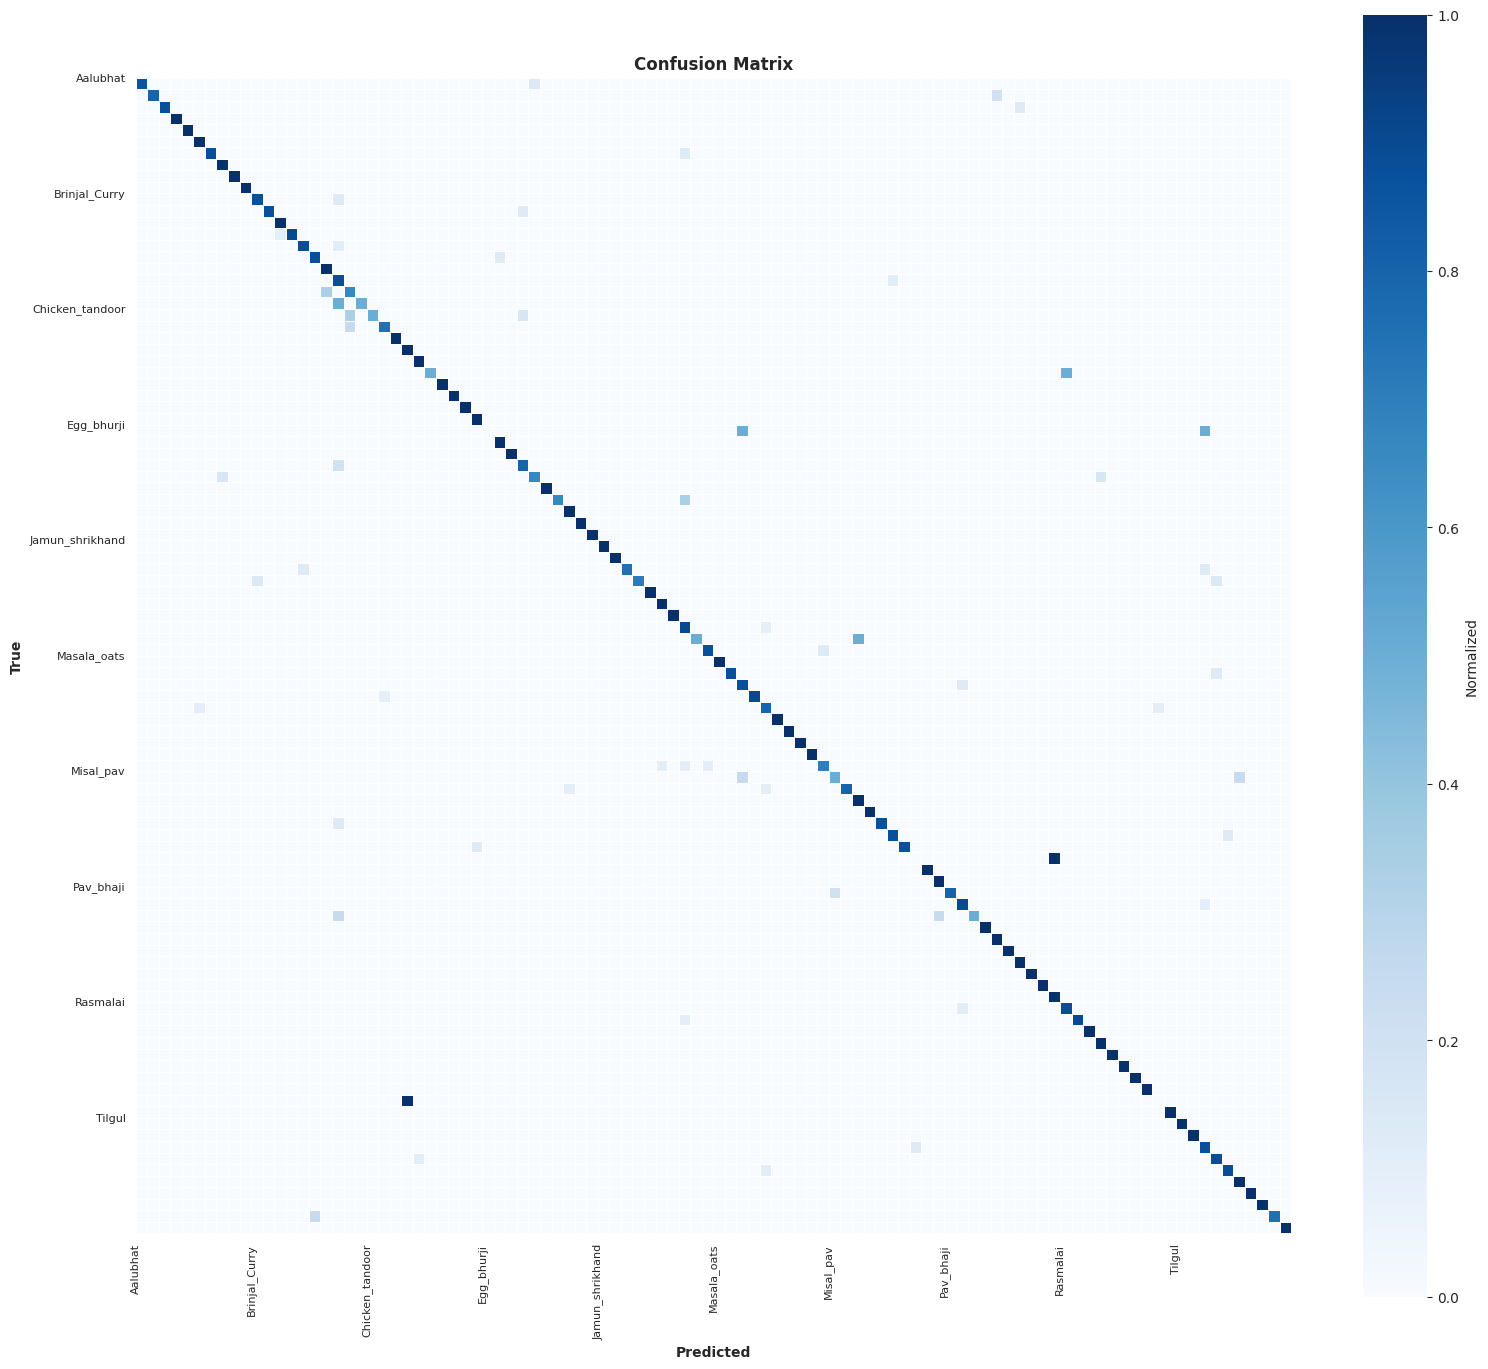

Saved: 07_confusion.png + confusion_matrix_100x100.csv


In [ ]:
# ===== CELL 25: CONFUSION MATRIX + plot 07 + CSV =====
cm = confusion_matrix(lbls, preds)
plt.figure(figsize=(16,14))
sns.heatmap(cm.astype(float)/cm.sum(axis=1)[:,None], cmap='Blues', square=True, linewidths=.5, cbar_kws={'label':'Normalized'})
tk = np.arange(0, len(class_names), 10)
plt.xticks(tk, [class_names[i] for i in tk], rotation=90, fontsize=8)
plt.yticks(tk, [class_names[i] for i in tk], rotation=0, fontsize=8)
plt.xlabel('Predicted', fontweight='bold'); plt.ylabel('True', fontweight='bold'); plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{cfg.PLOT_DIR}/07_confusion.png', dpi=200, bbox_inches='tight'); plt.show()
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(f'{cfg.PLOT_DIR}/confusion_matrix_100x100.csv')
print("Saved: 07_confusion.png + confusion_matrix_100x100.csv")

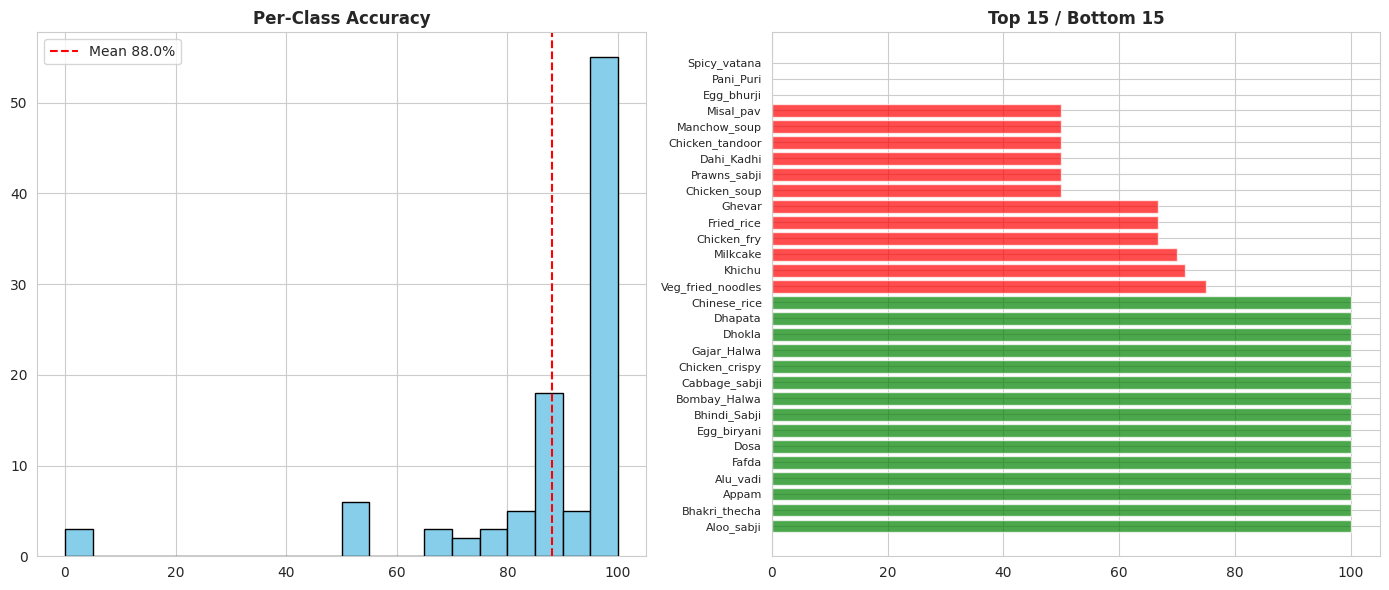

Mean 87.98% | Std 20.65%


In [ ]:
# ===== CELL 26: PER-CLASS ACCURACY + plot 08 =====
per_cls = cm.diagonal() / cm.sum(axis=1) * 100
dfc = pd.DataFrame({'Class':class_names, 'Acc':per_cls}).sort_values('Acc', ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].hist(per_cls, bins=20, color='skyblue', edgecolor='black')
ax[0].axvline(per_cls.mean(), color='red', ls='--', label=f'Mean {per_cls.mean():.1f}%')
ax[0].set_title('Per-Class Accuracy', fontweight='bold'); ax[0].legend()
tb = pd.concat([dfc.head(15), dfc.tail(15)])
ax[1].barh(range(len(tb)), tb['Acc'], color=['green']*15+['red']*15, alpha=.7)
ax[1].set_yticks(range(len(tb))); ax[1].set_yticklabels(tb['Class'], fontsize=8)
ax[1].set_title('Top 15 / Bottom 15', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{cfg.PLOT_DIR}/08_per_class.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Mean {per_cls.mean():.2f}% | Std {per_cls.std():.2f}%")

In [ ]:
# ===== CELL 27: CLASSIFICATION REPORT =====
rep = classification_report(lbls, preds, target_names=class_names, digits=3, output_dict=True, zero_division=0)
pd.DataFrame(rep).transpose().to_csv(f'{cfg.PLOT_DIR}/per_class_precision_recall_f1.csv')
print("Saved: per_class_precision_recall_f1.csv (S6)")

Saved: per_class_precision_recall_f1.csv (S6)


In [ ]:
# ===== CELL 28: SUMMARY REPORT =====
st = json.load(open(STATS_PATH)) if os.path.exists(STATS_PATH) else {'total':'?','valid':'?','corrupted':'?','verified':len(paths)}
summary = f"""
{'='*80}
TRAINING SUMMARY
{'='*80}
DATASET:  original {st['total']} | valid {st['valid']} | corrupted {st['corrupted']} | final {st['verified']} | classes {cfg.NUM_CLASSES}
SPLIT:    train {len(X_tr)} | val {len(X_val)} | test {len(X_tst)}
MODEL:    CNN-Transformer ({cfg.BACKBONE}) | {sum(p.numel() for p in model.parameters()):,} params
TRAIN:    epochs {cfg.EPOCHS} | batch {cfg.BATCH_SIZE} | best val {best:.2f}% | test {acc*100:.2f}%
PER-CLASS: mean {per_cls.mean():.2f}% | std {per_cls.std():.2f}% | best {dfc.iloc[0]['Class']} ({dfc.iloc[0]['Acc']:.1f}%) | worst {dfc.iloc[-1]['Class']} ({dfc.iloc[-1]['Acc']:.1f}%)

OUTPUTS -> {cfg.PLOT_DIR}
  class_metadata.csv, class_names.txt, training_log.csv, test_predictions.csv,
  confusion_matrix_100x100.csv, per_class_precision_recall_f1.csv (S6)
MODEL   -> {cfg.MODEL_DIR}/best.pth
{'='*80}
"""
print(summary)
with open(f'{cfg.PLOT_DIR}/summary.txt', 'w') as f: f.write(summary)
print("Saved: summary.txt")


TRAINING SUMMARY
DATASET:  original 4577 | valid 4577 | corrupted 0 | final 7 | classes 100
SPLIT:    train 3203 | val 687 | test 687
MODEL:    CNN-Transformer (resnet50) | 67,983,396 params
TRAIN:    epochs 50 | batch 64 | best val 91.41% | test 91.41%
PER-CLASS: mean 87.98% | std 20.65% | best Aloo_sabji (100.0%) | worst Spicy_vatana (0.0%)

OUTPUTS -> /content/drive/MyDrive/CEP_Food_Dataset/outputs
  class_metadata.csv, class_names.txt, training_log.csv, test_predictions.csv,
  confusion_matrix_100x100.csv, per_class_precision_recall_f1.csv (S6)
MODEL   -> /content/drive/MyDrive/CEP_Food_Dataset/models/best.pth

Saved: summary.txt
